# Slice 1 exploratory data analysis

This notebook checks the normalized UCI SMS Spam Collection before any training. It reports class balance, duplicate counts, missing values, and text-length distributions. The hand-curated chat evaluation set and additional email/phishing corpora will be analyzed in later slices without contaminating training data.

In [ ]:
# Import Path so the notebook works from its own directory.
from pathlib import Path

# Import Matplotlib for explicit figure construction.
import matplotlib.pyplot as plt
# Import pandas for labeled tabular analysis.
import pandas as pd
# Import Seaborn for readable statistical charts.
import seaborn as sns

# Resolve the ML project root from the notebooks directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# Point to the normalized file created by the download script.
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "sms_spam.csv"
# Stop with an actionable instruction when preparation has not run.
if not DATASET_PATH.exists():
    # Explain the exact command needed to create the local dataset.
    raise FileNotFoundError("Run: uv run python scripts/download_sms_spam.py")
# Load message text as strings while preserving the integer target.
messages = pd.read_csv(DATASET_PATH, dtype={"text": "string", "original_label": "string"})
# Derive character length without mutating the original text.
messages["character_count"] = messages["text"].str.len()
# Derive whitespace-token count as a simple register diagnostic.
messages["token_count"] = messages["text"].str.split().str.len()
# Display only aggregate shape and schema information, not message plaintext.
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   message_id       5574 non-null   object
 1   text             5574 non-null   string
 2   label            5574 non-null   int64 
 3   original_label   5574 non-null   string
 4   source           5574 non-null   object
 5   split            5574 non-null   object
 6   character_count  5574 non-null   Int64 
 7   token_count      5574 non-null   int64 
dtypes: Int64(1), int64(2), object(3), string(2)
memory usage: 353.9+ KB


In [ ]:
# Count examples in each canonical class.
class_counts = messages["label"].value_counts().sort_index()
# Convert class counts into proportions for imbalance assessment.
class_proportions = messages["label"].value_counts(normalize=True).sort_index()
# Count exact repeated text before any future train/test split.
duplicate_texts = int(messages.duplicated(subset=["text"]).sum())
# Count absent values that would invalidate vectorization.
missing_values = messages[["text", "label"]].isna().sum()
# Assemble the first-slice quality report from aggregate values.
quality_report = {
    # Record the complete normalized row count.
    "rows": len(messages),
    # Record class counts using readable labels.
    "class_counts": {"legitimate": int(class_counts.get(0, 0)), "scam": int(class_counts.get(1, 0))},
    # Record proportions for threshold and stratification planning.
    "class_proportions": {"legitimate": float(class_proportions.get(0, 0.0)), "scam": float(class_proportions.get(1, 0.0))},
    # Record exact duplicates that must not cross data splits.
    "duplicate_texts": duplicate_texts,
    # Record missing values by required field.
    "missing_values": missing_values.to_dict(),
}
# Render the aggregate report as the cell result.
quality_report

{'rows': 5574,
 'class_counts': {'legitimate': 4827, 'scam': 747},
 'class_proportions': {'legitimate': 0.8659849300322928,
  'scam': 0.1340150699677072},
 'duplicate_texts': 403,
 'missing_values': {'text': 0, 'label': 0}}

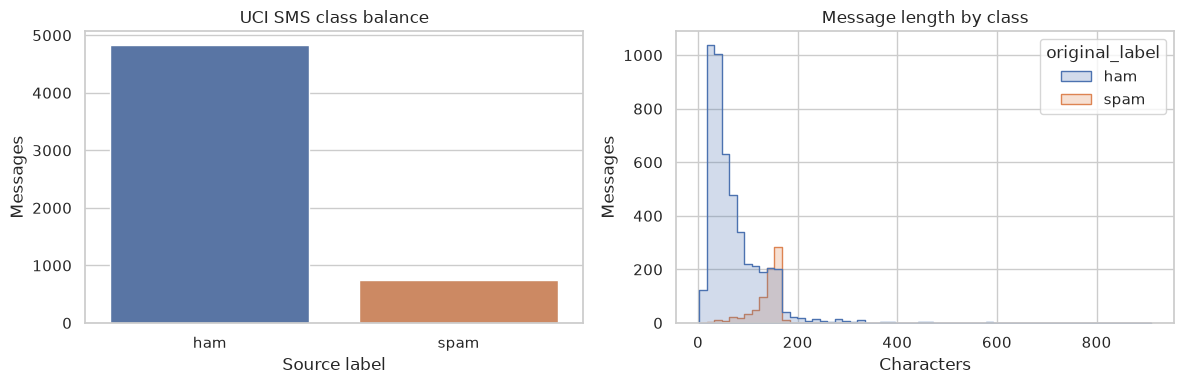

In [ ]:
# Give plots a consistent accessible visual theme.
sns.set_theme(style="whitegrid")
# Create one panel for balance and one for text-length distributions.
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
# Plot the number of legitimate and scam-labeled examples.
sns.countplot(data=messages, x="original_label", hue="original_label", legend=False, ax=axes[0])
# Explain what the first chart measures.
axes[0].set_title("UCI SMS class balance")
# Label the categorical source target axis.
axes[0].set_xlabel("Source label")
# Label the sample-count axis.
axes[0].set_ylabel("Messages")
# Compare character-count distributions without showing message content.
sns.histplot(data=messages, x="character_count", hue="original_label", bins=60, element="step", ax=axes[1])
# Explain what the second chart measures.
axes[1].set_title("Message length by class")
# Label the measured length unit.
axes[1].set_xlabel("Characters")
# Label the frequency axis.
axes[1].set_ylabel("Messages")
# Prevent labels from overlapping within the saved notebook view.
figure.tight_layout()
# Display the complete EDA figure.
plt.show()